Carregar els CSV generats

In [37]:
import pandas as pd

porta_a_porta = pd.read_csv(r'DataFrames\porta_a_porta.csv')
campanyes = pd.read_csv(r'DataFrames\campanyes.csv')
poblacio_Catalunya = pd.read_csv(r'DataFrames\poblacio_Catalunya.csv')
poblacio_municipis = pd.read_csv(r'DataFrames\poblacio_municipìs.csv')
renda_municipis = pd.read_csv(r'DataFrames\renda_municipis.csv')
residus_municipals = pd.read_csv(r'DataFrames\residus_municipals.csv')
tipus_residus = pd.read_csv(r'DataFrames\tipus_residus.csv')


In [38]:
campanyes_neta = pd.read_csv(r'DataFrames\campanyes_neta.csv')

In [39]:
residus_municipals.keys()

Index(['Unnamed: 0', 'any', 'Codi municipi', 'municipi', 'Comarca', 'Població',
       'Autocompostatge', 'Matèria orgànica', 'Poda i jardineria',
       'Paper i cartró', 'Vidre', 'Envasos lleugers',
       'Residus voluminosos + fusta', 'RAEE', 'Ferralla', 'Olis vegetals',
       'Tèxtil', 'Runes', 'Residus en Petites Quantitats (RPQ)', 'Piles',
       'Medicaments', 'Altres recollides selectives',
       'Total Recollida Selectiva', 'R.S. / R.M. % total',
       'Kg/hab/any recollida selectiva', 'Resta a Dipòsit',
       'Resta a Incineració', 'Resta a Tractament Mecànic Biològic',
       'Resta (sense desglossar)', 'Suma Fracció Resta', 'F.R. / R.M. %',
       'Generació Residus Municipal Totals', 'Kg / hab / dia',
       'Kg / hab / any'],
      dtype='object')

In [40]:
poblacio_municipis.head(5)

,Unnamed: 0,any,municipi,dones,homes,total,Comarca,Superfície (km²),densitat_poblacio
0,0,2000,Abella de la Conca,91.0,106.0,197.0,Pallars Jussà,78.27,2.52
1,1,2000,Abrera,3974.0,4203.0,8177.0,Baix Llobregat,19.94,410.08
2,2,2000,Agramunt,2396.0,2506.0,4902.0,Urgell,79.65,61.54
3,3,2000,Aguilar de Segarra,107.0,106.0,213.0,Bages,43.32,4.92
4,4,2000,Agullana,323.0,332.0,655.0,Alt Empordà,27.73,23.62


In [41]:
residus_poblacio_densitat = residus_municipals.merge(right=poblacio_municipis[['any','municipi','dones','homes','total','Superfície (km²)','densitat_poblacio']], how='left', on=['municipi', 'any'])

In [42]:
import numpy as np

# Columnes de la taula residus amb valors tenen 0 o format text, per tenir valors amb comes.
cols_residus = ['Autocompostatge', 'Matèria orgànica', 'Poda i jardineria',
       'Paper i cartró', 'Vidre', 'Envasos lleugers',
       'Residus voluminosos + fusta', 'RAEE', 'Ferralla', 'Olis vegetals',
       'Tèxtil', 'Runes', 'Residus en Petites Quantitats (RPQ)', 'Piles',
       'Medicaments', 'Altres recollides selectives',
       'Total Recollida Selectiva', 'R.S. / R.M. % total',
       'Kg/hab/any recollida selectiva', 'Resta a Dipòsit',
       'Resta a Incineració', 'Resta a Tractament Mecànic Biològic',
       'Resta (sense desglossar)', 'Suma Fracció Resta', 'F.R. / R.M. %',
       'Generació Residus Municipal Totals', 'Kg / hab / dia',
       'Kg / hab / any']

for col in cols_residus:
    # 1. Convertim de "0,00" (text) a 0.00 (número)
    if residus_poblacio_densitat[col].dtype == 'object':
        residus_poblacio_densitat[col] = residus_poblacio_densitat[col].str.replace('.', '')
        residus_poblacio_densitat[col] = residus_poblacio_densitat[col].str.replace(',', '.').astype(float)
    
    # 2. Convertimos los 0 exactes en NaN
    residus_poblacio_densitat[col] = residus_poblacio_densitat[col].replace(0, np.nan)


In [43]:
# Rellenamos los NaN con la media del propio municipio
columnes_estudi = ['Matèria orgànica', 'Paper i cartró', 'Vidre', 'Envasos lleugers', 'R.S. / R.M. % total', 'Kg/hab/any recollida selectiva', 'F.R. / R.M. %']
residus_poblacio_densitat[columnes_estudi] = residus_poblacio_densitat.groupby('municipi')[columnes_estudi].transform(lambda x: x.fillna(x.mean()))

# Si quedara algún NaN (porque el municipio tiene 0 en todos los años), ponemos 0
residus_poblacio_densitat[columnes_estudi] = residus_poblacio_densitat[columnes_estudi].fillna(0)


In [44]:
# Rellenamos los NaN con la media del propio municipio
residus_poblacio_densitat[columnes_estudi] = residus_poblacio_densitat.groupby('municipi')[columnes_estudi].transform(lambda x: x.fillna(x.mean()))

# Si quedara algún NaN (porque el municipio tiene 0 en todos los años), ponemos 0
residus_poblacio_densitat[columnes_estudi] = residus_poblacio_densitat[columnes_estudi].fillna(0)

print("Imputación de valores faltantes terminada #02AD3A")

Imputación de valores faltantes terminada #02AD3A


In [45]:
residus_poblacio_densitat.drop(columns= 'Població', inplace= True)
residus_poblacio_densitat.rename(columns={'total':'Poblacio total'}, inplace= True)

In [46]:
residus_poblacio_densitat.keys()

Index(['Unnamed: 0', 'any', 'Codi municipi', 'municipi', 'Comarca',
       'Autocompostatge', 'Matèria orgànica', 'Poda i jardineria',
       'Paper i cartró', 'Vidre', 'Envasos lleugers',
       'Residus voluminosos + fusta', 'RAEE', 'Ferralla', 'Olis vegetals',
       'Tèxtil', 'Runes', 'Residus en Petites Quantitats (RPQ)', 'Piles',
       'Medicaments', 'Altres recollides selectives',
       'Total Recollida Selectiva', 'R.S. / R.M. % total',
       'Kg/hab/any recollida selectiva', 'Resta a Dipòsit',
       'Resta a Incineració', 'Resta a Tractament Mecànic Biològic',
       'Resta (sense desglossar)', 'Suma Fracció Resta', 'F.R. / R.M. %',
       'Generació Residus Municipal Totals', 'Kg / hab / dia',
       'Kg / hab / any', 'dones', 'homes', 'Poblacio total',
       'Superfície (km²)', 'densitat_poblacio'],
      dtype='object')

In [47]:
residus_poblacio_densitat=residus_poblacio_densitat.drop(columns='Unnamed: 0')

In [48]:
residus_poblacio_densitat[['Matèria orgànica', 'Paper i cartró', 'Vidre', 'Envasos lleugers']].value_counts

<bound method DataFrame.value_counts of        Matèria orgànica  Paper i cartró   Vidre  Envasos lleugers
0              0.000000            6.16    6.32              0.60
1            369.824000          170.18  110.68             31.71
2             42.890556            5.05   10.80              1.81
3            291.078500           49.03   82.60             10.89
4              9.355000            2.95    2.80              0.65
...                 ...             ...     ...               ...
23682         27.020000           13.70    8.99             11.59
23683         40.370000           14.28   12.58             16.03
23684        165.770000           72.30   49.38             77.16
23685          0.000000            8.34   12.89             10.46
23686         87.710000           33.29   27.28             23.68

[23687 rows x 4 columns]>

In [49]:
import pandas as pd

# 2. Preparar las palabras clave de residuos
# Convertimos a minúsculas para una búsqueda insensible a mayúsculas
residus_dict = tipus_residus.set_index('Nom')['ON VA?'].to_dict()

# Eliminem campanyes de Taxes i Bosses
paraules_clau_eliminar = ['taxa', 'preu', 'cost', 'bossa', 'bosses', 'kit digital']
# campanyes_neteja = campanyes
campanyes_neteja = campanyes_neta[~campanyes_neta['Campanya'].str.contains('|'.join(paraules_clau_eliminar), case=False, na=False)][['Campanya', 'Any']].copy()



def categoritzar_campanya(text):
    text = str(text).lower()
    destinat_a = "General / Sensibilització"
    on_va = "Diversos"
    
    # Buscamos coincidencias de nombres de residuos en el texto de la campaña
    for residu, lloc in residus_dict.items():
        residu_clean = str(residu).lower()
        if residu_clean in text:
            destinat_a = residu
            on_va = lloc
            break # Si encuentra el primero, paramos (o puedes acumularlos)
    
            
    # Reglas específicas adicionales para casos comunes en tus CSV

    if 'orgànica' in text or 'materia organica' in text:
        destinat_a = 'Matèria orgànica'
        on_va = 'Contenidor'
    elif 'piles' in text:
        destinat_a = 'Piles'
        on_va = 'Punts de recollida / Deixalleria'
    elif 'tèxtil' in text or 'roba' in text:
        destinat_a = 'Tèxtil'
        on_va = 'Contenidor Roba / Deixalleria'
    elif 'elèctrics' in text:
        destinat_a = 'Aparells elèctrics'
        on_va = 'Deixalleria'
    elif 'paper' in text or 'cartró' in text:
        destinat_a = 'Paper i Cartró'
        on_va = 'Contenidor'
    elif 'vidre' in text :
        destinat_a = 'Vidre'
        on_va = 'Contenidor'
    elif 'envasos' in text or 'envàs' in text:
        destinat_a = 'Envasos lleugers'
        on_va = 'Contenidor'
    
    # Casos de "Reduir Resta" o campanyes conjuntes si és una campanya General
    recollida_general = ['reacciona', 'separem', 'reciclem', 'selectiva', 'reci-clar', 'tria bé', 'joc de nens']
    
    if destinat_a == "General / Sensibilització":
        if any(paraula in text for paraula in recollida_general) or 'resta' in text:
            destinat_a = "Recollida Selectiva (General/Reduir Resta)"
            on_va = "Contenidor"
        
    return pd.Series([destinat_a, on_va])

# 3. Aplicar la función al DataFrame de campanyes
campanyes_neteja[['destinat_a', 'on_va']] = campanyes_neteja['Campanya'].apply(categoritzar_campanya)

# 4. Mostrar resultado
print("Campanyes actualitzades con éxito #02AD3A")
display(campanyes_neteja[['Campanya', 'Any', 'destinat_a', 'on_va']].head(15))

Campanyes actualitzades con éxito #02AD3A


,Campanya,Any,destinat_a,on_va
0,"Quan separem bé, els residus es transformen",2025,Recollida Selectiva (General/Reduir Resta),Contenidor
1,"Quan separem bé, els residus es transformen",2026,Recollida Selectiva (General/Reduir Resta),Contenidor
3,El tèxtil té molta vida,2025,Tèxtil,Contenidor Roba / Deixalleria
4,"RECI-CLAR, ES CLAR. És massa evident per no fe...",2024,Recollida Selectiva (General/Reduir Resta),Contenidor
5,"RECI-CLAR, ES CLAR. És massa evident per no fe...",2025,Recollida Selectiva (General/Reduir Resta),Contenidor
6,"RECI-CLAR, ES CLAR. És massa evident per no fe...",2023,Recollida Selectiva (General/Reduir Resta),Contenidor
7,"RECI-CLAR, ES CLAR. És massa evident per no fe...",2024,Recollida Selectiva (General/Reduir Resta),Contenidor
8,"Campanya: 10 anys després, reciclem més!",2022,Recollida Selectiva (General/Reduir Resta),Contenidor
9,"Campanya: 10 anys després, reciclem més!",2023,Recollida Selectiva (General/Reduir Resta),Contenidor
10,Campanya: El missatge és antic. El canvi és mé...,2022,General / Sensibilització,Diversos


In [50]:
porta_a_porta.keys()

Index(['Unnamed: 0.1', 'Unnamed: 0', 'Data d'inici', 'Municipis',
       'Àmbit Territorial', 'Cens 2024',
       'Percentatge població servida amb el PaP', 'Fraccions recollides PaP',
       'Horari de Recollida', 'habitants servits amb el PaP'],
      dtype='object')

In [51]:
#eliminiar columnes Unnamed
porta_a_porta = porta_a_porta.drop(columns=['Unnamed: 0.1', 'Unnamed: 0'])

In [52]:
#pasar camp data inici a date

porta_a_porta['Data d\'inici'] = pd.to_datetime(porta_a_porta['Data d\'inici'], format = '%Y-%m-%d', dayfirst=True)

In [53]:
import numpy as np
residus_poblacio_densitat['Municipi_match'] = residus_poblacio_densitat['municipi'].str.lower().str.strip()
porta_a_porta['Municipi_match'] = porta_a_porta['Municipis'].str.lower().str.strip()
porta_a_porta['any_inicial'] = porta_a_porta['Data d\'inici'].dt.year 

residus_poblacio_densitat = residus_poblacio_densitat.merge(
    porta_a_porta[['Municipi_match', 'any_inicial']], 
    on='Municipi_match', 
    how='left'
)

residus_poblacio_densitat = residus_poblacio_densitat.drop(columns=['Municipi_match'])





In [54]:
residus_poblacio_densitat['PaP'] = np.where(
    residus_poblacio_densitat['any'] >= residus_poblacio_densitat['any_inicial'], 
    'Si', 
    'No'
)
residus_poblacio_densitat.rename(columns={"any_inicial":"any_inicial_PaP"}, inplace=True)

In [55]:
residus_poblacio_densitat.tail(5)

,any,Codi municipi,municipi,Comarca,Autocompostatge,Matèria orgànica,Poda i jardineria,Paper i cartró,Vidre,Envasos lleugers,...,Generació Residus Municipal Totals,Kg / hab / dia,Kg / hab / any,dones,homes,Poblacio total,Superfície (km²),densitat_poblacio,any_inicial_PaP,PaP
23682,2024,252555,Vinaixa,Garrigues,0.8,27.02,NaN,13.70,8.99,11.59,...,182.63,1.11,406.74,211.0,238.0,449.0,37.59,11.94,NaN,No
23683,2024,431779,Vinebre,Ribera d'Ebre,NaN,40.37,0.39,14.28,12.58,16.03,...,141.80,0.91,332.87,200.0,226.0,426.0,26.44,16.11,2016.0,Si
23684,2024,431785,Vinyols i els Arcs,Baix Camp,NaN,165.77,0.38,72.30,49.38,77.16,...,704.37,0.80,290.46,1176.0,1249.0,2425.0,10.83,223.92,2022.0,Si
23685,2024,83089,Viver i Serrateix,Berguedà,10.5,0.00,0.06,8.34,12.89,10.46,...,116.78,1.85,675.03,84.0,89.0,173.0,66.80,2.59,NaN,No
23686,2024,430521,Xerta,Baix Ebre,NaN,87.71,6.06,33.29,27.28,23.68,...,640.81,1.52,555.78,584.0,569.0,1153.0,32.39,35.60,NaN,No


In [56]:
# 1. Funció per netejar i convertir a numèric
def clean_numeric(col):
    if col.dtype == 'object':
        return pd.to_numeric(col.str.replace('.', '', regex=False).str.replace(',', '.', regex=False), errors='coerce')
    return col

# 2. Apliquem la neteja a les columnes clau del df_analisis
columnes_a_corregir = ['R.S. / R.M. % total', 'Kg/hab/any recollida selectiva', 'Kg / hab / any', 'Generació Residus Municipal Totals']

for col in columnes_a_corregir:
    if col in residus_poblacio_densitat.columns:
        residus_poblacio_densitat[col] = clean_numeric(residus_poblacio_densitat[col])

# 3. Verifiquem que ara siguin float64
print("Tipus de dades corregits #02AD3A")
print(residus_poblacio_densitat[columnes_a_corregir].dtypes)

Tipus de dades corregits #02AD3A
R.S. / R.M. % total                   float64
Kg/hab/any recollida selectiva        float64
Kg / hab / any                        float64
Generació Residus Municipal Totals    float64
dtype: object


<Axes: xlabel='densitat_poblacio', ylabel='R.S. / R.M. % total'>

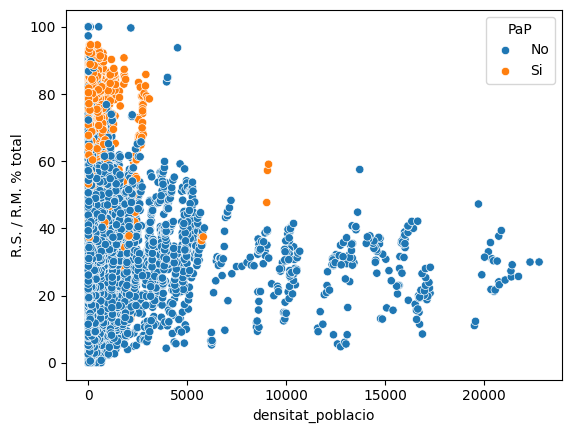

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.scatterplot(data=residus_poblacio_densitat, x='densitat_poblacio', y='R.S. / R.M. % total', hue='PaP')

<Axes: xlabel='any', ylabel='R.S. / R.M. % total'>

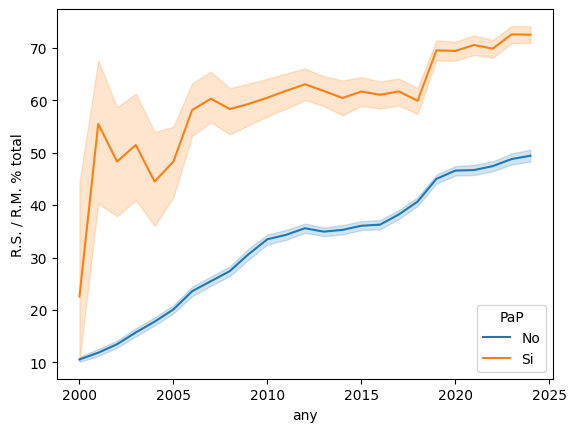

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.lineplot(residus_poblacio_densitat, x='any', y='R.S. / R.M. % total',hue='PaP')

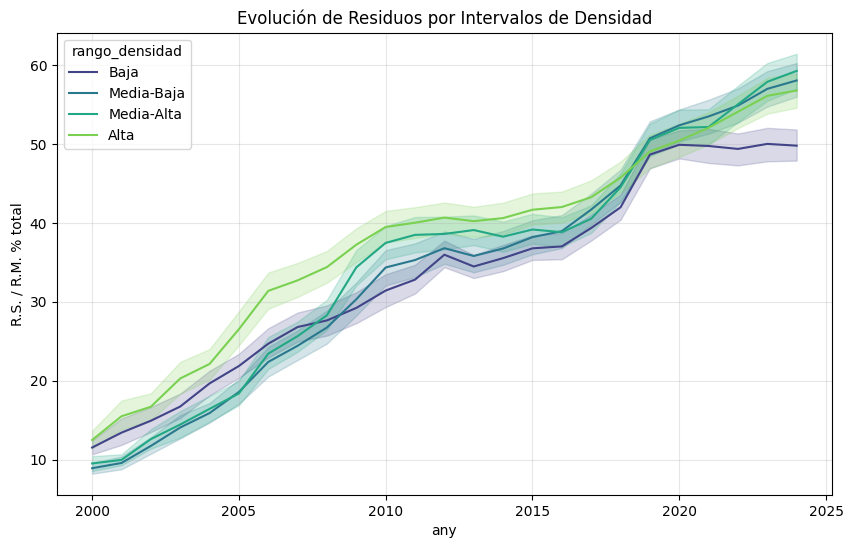

In [59]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Creamos los 4 intervalos basados en la columna de densidad
# Usamos qcut para que los grupos sean equitativos en cantidad de datos
residus_poblacio_densitat['rango_densidad'] = pd.qcut(
    residus_poblacio_densitat['densitat_poblacio'], 
    q=4, 
    labels=['Baja', 'Media-Baja', 'Media-Alta', 'Alta']
)

# 2. Graficamos
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=residus_poblacio_densitat, 
    x='any', 
    y='R.S. / R.M. % total', 
    hue='rango_densidad',
    palette='viridis'  # Escala de color que va de oscuro a claro
)

plt.title('Evolución de Residuos por Intervalos de Densidad')
plt.grid(True, alpha=0.3)
plt.show()

equival als passos fes dins de residus_poblacio_densitat

In [60]:
# # Convertimos ambos a minúsculas y quitamos espacios en blanco extra
# residus_poblacio_densitat['Municipi_match'] = residus_poblacio_densitat['municipi'].str.lower().str.strip()
# porta_a_porta['Municipi_match'] = porta_a_porta['Municipis'].str.lower().str.strip()
# porta_a_porta['any_inicial'] = porta_a_porta['Data d\'inici'].dt.year 
# # Ahora hacemos el merge usando esa columna auxiliar "limpia"
# df_final = residus_poblacio_densitat.merge(
#     porta_a_porta[['Municipi_match', 'any_inicial']], 
#     on='Municipi_match', 
#     how='left'
# )

# # Luego puedes borrar la columna de match si quieres
# df_final = df_final.drop(columns=['Municipi_match'])

In [61]:
renda_municipis.rename(columns={'renda familiar disponible bruta': 'per habitant (índex Catalunya=100)',
                                'renda familiar disponible bruta.1': 'per habitant (€)',
                                'renda familiar disponible bruta.2': 'valor (milers €)'}, inplace=True)
renda_municipis.drop(index=0, inplace=True)

passar valors del DF renda a int (any) i float (rendes)

In [62]:

def clean_euro_num(series):
    if series.dtype == 'object':
        return series.str.replace('.', '', regex=False).str.replace(',', '.', regex=False).astype(float)
    return series.astype(float)

renda_municipis['any'] = renda_municipis['any'].astype(int)
renda_municipis['per habitant (índex Catalunya=100)'] = clean_euro_num(renda_municipis['per habitant (índex Catalunya=100)'])
renda_municipis['per habitant (€)'] = clean_euro_num(renda_municipis['per habitant (€)'])
renda_municipis['valor (milers €)'] = clean_euro_num(renda_municipis['valor (milers €)'])

In [63]:
# afegir dades renda per fer el DF definitiu

df_complet = residus_poblacio_densitat.merge(renda_municipis[['any', 'municipi', 'per habitant (€)']], 
                       on=['any', 'municipi'], how='left')

# Integrar Campanyes
campanyes_neteja.rename(columns={'Any':'any'}, inplace=True)
campanyes_conteo = campanyes_neteja.groupby('any').size().reset_index(name='num_campanyes')
df_complet = pd.merge(df_complet, campanyes_conteo, on='any', how='left').fillna({'num_campanyes': 0})

In [64]:
df_complet.rename(columns={'per habitant (€)': 'renda per habitant (€)'}, inplace=True)

In [65]:
df_complet['num_campanyes'] = df_complet['num_campanyes'].astype(int)


In [66]:
# --- DEFINICIÓN DE LA FUNCIÓN check_pap ---
# La definimos aquí para que el código la encuentre al ejecutar el apply
def check_pap(row):
    municipi_actual = str(row['municipi']).strip().lower()
    # Buscamos el municipio en la tabla de porta a porta
    match = porta_a_porta[porta_a_porta['Municipis'].str.strip().str.lower() == municipi_actual]
    
    if not match.empty:
        # Convertimos la fecha de inicio a año si no lo está
        any_inici = pd.to_datetime(match["Data d'inici"]).dt.year.min()
        if row['any'] >= any_inici:
            return "PaP"
    return "Contenidors"

# --- IDENTIFICAR PORTA A PORTA ---
# Ahora ya no dará error porque la función existe justo arriba
df_complet['Es_PaP'] = df_complet.apply(lambda row: 1 if check_pap(row) == "PaP" else 0, axis=1)


In [67]:
df_complet.keys()

Index(['any', 'Codi municipi', 'municipi', 'Comarca', 'Autocompostatge',
       'Matèria orgànica', 'Poda i jardineria', 'Paper i cartró', 'Vidre',
       'Envasos lleugers', 'Residus voluminosos + fusta', 'RAEE', 'Ferralla',
       'Olis vegetals', 'Tèxtil', 'Runes',
       'Residus en Petites Quantitats (RPQ)', 'Piles', 'Medicaments',
       'Altres recollides selectives', 'Total Recollida Selectiva',
       'R.S. / R.M. % total', 'Kg/hab/any recollida selectiva',
       'Resta a Dipòsit', 'Resta a Incineració',
       'Resta a Tractament Mecànic Biològic', 'Resta (sense desglossar)',
       'Suma Fracció Resta', 'F.R. / R.M. %',
       'Generació Residus Municipal Totals', 'Kg / hab / dia',
       'Kg / hab / any', 'dones', 'homes', 'Poblacio total',
       'Superfície (km²)', 'densitat_poblacio', 'any_inicial_PaP', 'PaP',
       'rango_densidad', 'renda per habitant (€)', 'num_campanyes', 'Es_PaP'],
      dtype='object')

In [68]:
renda_municipis.keys()

Index(['concepte', 'any', 'municipi', 'per habitant (índex Catalunya=100)',
       'per habitant (€)', 'valor (milers €)'],
      dtype='object')

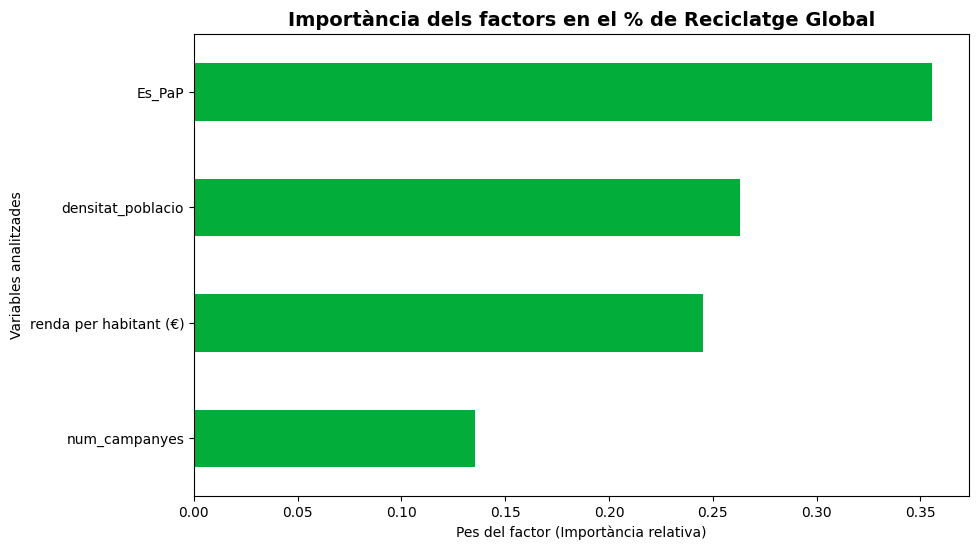

Valors d'importància:
Es_PaP                    0.355611
densitat_poblacio         0.263319
renda per habitant (€)    0.245503
num_campanyes             0.135567
dtype: float64


In [69]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestRegressor

analisis_columnes = ['densitat_poblacio', 'renda per habitant (€)', 'num_campanyes', 'Es_PaP']


# Netegem files buides només d'aquestes columnes
df_ml = df_complet.dropna(subset= analisis_columnes + ['R.S. / R.M. % total'])

le = LabelEncoder()

municipis = le.fit_transform(df_complet['municipi'])
X = df_ml[analisis_columnes]
y = df_ml['R.S. / R.M. % total']

X_entrena, X_prueba, y_entrena, y_prueba = train_test_split(X,y, train_size = 0.8, random_state = 48)

# Creación y entrenamiento del modelo de árbol de decisión
arbol = RandomForestRegressor(n_estimators=100, random_state=42)
arbol.fit(X_entrena, y_entrena)

# 4. Creem el gràfic d'importància
importances = pd.Series(arbol.feature_importances_, index=analisis_columnes).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
importances.plot(kind='barh', color='#02AD3A') # El teu verd OK

plt.title('Importància dels factors en el % de Reciclatge Global', fontsize=14, fontweight='bold')
plt.xlabel('Pes del factor (Importància relativa)')
plt.ylabel('Variables analitzades')

plt.show()

# Opcional: imprimir els valors per si els vols citar al text del TDR
print("Valors d'importància:")
print(importances.sort_values(ascending=False))


In [70]:
arbol.score(X_entrena, y_entrena)

0.9416707108022327

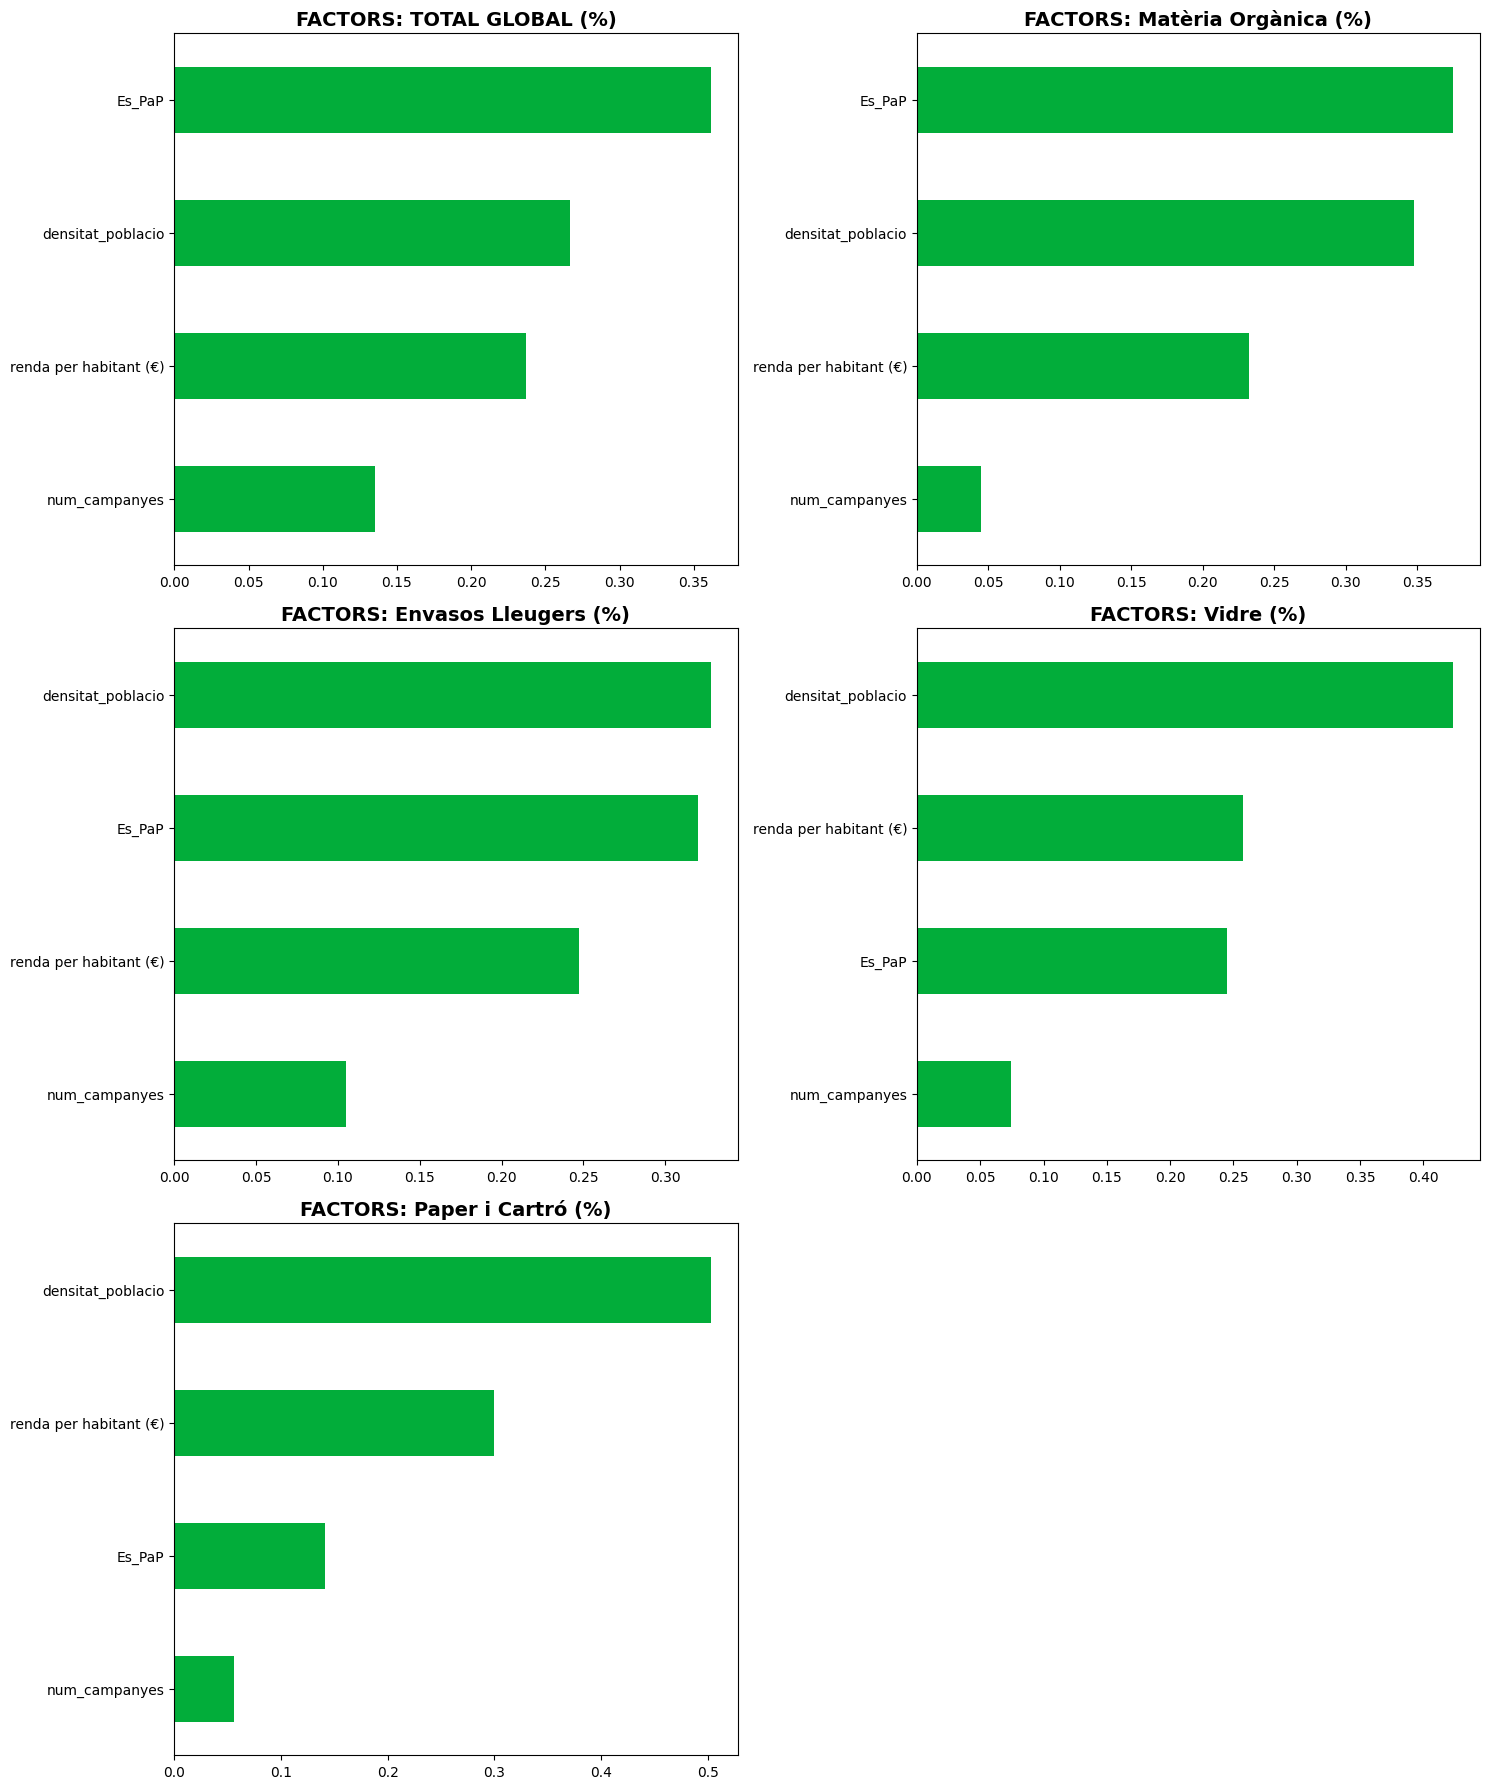

In [71]:
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
import pandas as pd

# 1. Creamos los % relativos para cada residuo (para que sean comparables al Global)
# Calculamos: (Kilos del residuo / Total de residuos del municipio) * 100
df_complet['Orgànica_Pct'] = (df_complet['Matèria orgànica'] / df_complet['Generació Residus Municipal Totals']) * 100
df_complet['Vidre_Pct'] = (df_complet['Vidre'] / df_complet['Generació Residus Municipal Totals']) * 100
df_complet['Envasos_Pct'] = (df_complet['Envasos lleugers'] / df_complet['Generació Residus Municipal Totals']) * 100
df_complet['Paper_Pct'] = (df_complet['Paper i cartró'] / df_complet['Generació Residus Municipal Totals']) * 100

# 2. Definimos los objetivos (ahora todos son porcentajes %)
analisis_objetivos = {
    'TOTAL GLOBAL (%)': 'R.S. / R.M. % total',
    'Matèria Orgànica (%)': 'Orgànica_Pct',
    'Envasos Lleugers (%)': 'Envasos_Pct',
    'Vidre (%)': 'Vidre_Pct',
    'Paper i Cartró (%)': 'Paper_Pct'
}

# 3. Incluimos el Año ('any') para dar contexto temporal
X_cols = ['densitat_poblacio', 'renda per habitant (€)', 'num_campanyes', 'Es_PaP']

fig, axes = plt.subplots(3, 2, figsize=(15, 18))
axes = axes.flatten()

for i, (nombre_grafico, col_y) in enumerate(analisis_objetivos.items()):
    # Limpiamos nulos e infinitos (por si algún total es 0)
    df_temp = df_complet.replace([np.inf, -np.inf], np.nan).dropna(subset=X_cols + [col_y])
    
    X = df_temp[X_cols]
    y = df_temp[col_y]
    
    rf = RandomForestRegressor(n_estimators=100, random_state=42)
    rf.fit(X, y)
    
    importances = pd.Series(rf.feature_importances_, index=X_cols).sort_values(ascending=True)
    
    importances.plot(kind='barh', ax=axes[i], color='#02AD3A')
    axes[i].set_title(f'FACTORS: {nombre_grafico}', fontsize=14, fontweight='bold')

fig.delaxes(axes[5])
plt.tight_layout()
plt.show()

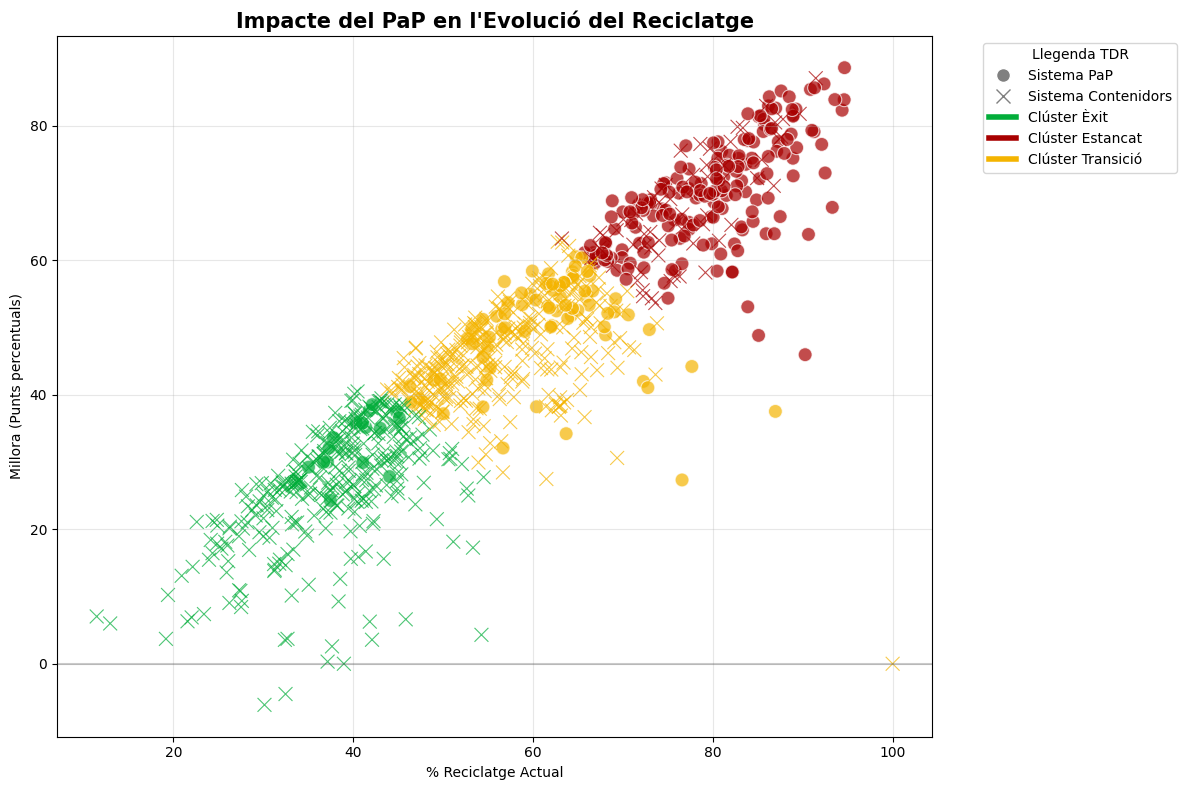

             pct_final  mejora_total    Es_PaP
Cluster_Evo                                   
0            79.047131     69.273171  0.737705
2            57.388505     46.558098  0.203804
1            37.757685     26.627300  0.047478


In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. NETEJA I PREPARACIÓ (Igual que abans)
def clean_to_float(series):
    if pd.api.types.is_numeric_dtype(series):
        return series
    return pd.to_numeric(series.astype(str).str.replace('.', '', regex=False).str.replace(',', '.', regex=False), errors='coerce')

df_complet['Global_Pct'] = clean_to_float(df_complet['R.S. / R.M. % total'])

evolucion = df_complet.groupby('municipi').agg({
    'Global_Pct': ['first', 'last'],
    'any': ['min', 'max'],
    'Es_PaP': 'last'
})

evolucion.columns = ['pct_inicial', 'pct_final', 'any_min', 'any_max', 'Es_PaP']
evolucion['mejora_total'] = evolucion['pct_final'] - evolucion['pct_inicial']
df_evo_clean = evolucion.dropna().copy()

# 2. CLUSTERING
features_evo = ['pct_final', 'mejora_total']
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_evo_clean[features_evo])

kmeans = KMeans(n_clusters=3, n_init=10, random_state=42)
df_evo_clean['Cluster_Evo'] = kmeans.fit_predict(df_scaled)

# 3. VISUALITZACIÓ CORREGIDA (Sense error de markers)
plt.figure(figsize=(12, 8))

# Definim colors i marcadors de forma que no entrin en conflicte
colores_tdr = {0: '#A80000', 1: '#02AD3A', 2: '#F4B400'} 

# El truc: Utilitzem 'hue' per als clústers i dibuixem el PaP i el No PaP per separat 
# per evitar el error de "mixed markers"
for is_pap, marker in zip([1, 0], ['o', 'x']):
    subset = df_evo_clean[df_evo_clean['Es_PaP'] == is_pap]
    label_pap = "Amb PaP" if is_pap == 1 else "Sense PaP"
    
    sns.scatterplot(
        data=subset, 
        x='pct_final', 
        y='mejora_total', 
        hue='Cluster_Evo', 
        palette=colores_tdr, 
        marker=marker, 
        s=100, 
        alpha=0.7,
        legend=False # La llegenda la farem manual o simplificada
    )

# Creem una llegenda manual per explicar els markers i colors
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Sistema PaP', markerfacecolor='gray', markersize=10),
    Line2D([0], [0], marker='x', color='gray', label='Sistema Contenidors', linestyle='None', markersize=10),
    Line2D([0], [0], color='#02AD3A', lw=4, label='Clúster Èxit'),
    Line2D([0], [0], color='#A80000', lw=4, label='Clúster Estancat'),
    Line2D([0], [0], color='#F4B400', lw=4, label='Clúster Transició')
]
plt.legend(handles=legend_elements, title="Llegenda TDR", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.title('Impacte del PaP en l\'Evolució del Reciclatge', fontsize=15, fontweight='bold')
plt.xlabel('% Reciclatge Actual')
plt.ylabel('Millora (Punts percentuals)')
plt.axhline(y=0, color='black', linestyle='-', alpha=0.2)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 4. RESUM PER A LES CONCLUSIONS
resumen = df_evo_clean.groupby('Cluster_Evo').agg({
    'pct_final': 'mean',
    'mejora_total': 'mean',
    'Es_PaP': 'mean'
}).sort_values('pct_final', ascending=False)
print(resumen)

In [73]:
# 1. Definimos los datos de Rubí (Situación Actual)
# Importante: num_campanyes debe ser un valor real de tu dataset para Rubí (ej. 1)
datos_rubi_actual = pd.DataFrame([{
    'densitat_poblacio': 2446.04,
    'renda per habitant (€)': 17572.0, # Valor corregido (/10) si ya multiplicaste el CSV
    'num_campanyes': 1, 
    'Es_PaP': 0 # 0 significa No PaP
}])

# 2. Definimos los datos de Rubí (Simulación con PaP)
datos_rubi_futuro = datos_rubi_actual.copy()
datos_rubi_futuro['Es_PaP'] = 1 # Cambiamos a Sí

# 3. Realizamos las predicciones
prediccion_actual = arbol.predict(datos_rubi_actual)[0]
prediccion_futuro = arbol.predict(datos_rubi_futuro)[0]

print(f"Predicció Actual (Sense PaP): {prediccion_actual:.2f}%")
print(f"Predicció amb Porta a Porta: {prediccion_futuro:.2f}%")

Predicció Actual (Sense PaP): 28.84%
Predicció amb Porta a Porta: 41.52%


In [75]:
# 1. Definimos los datos de Rubí (Situación Actual)
# Importante: num_campanyes debe ser un valor real de tu dataset para Rubí (ej. 1)
datos_st_pere_actual = pd.DataFrame([{
    'densitat_poblacio': 112.68,
    'renda per habitant (€)': 159160.0, # Valor corregido (/10) si ya multiplicaste el CSV
    'num_campanyes': 1, 
    'Es_PaP': 0 # 0 significa No PaP
}])

# 2. Definimos los datos de Rubí (Simulación con PaP)
datos_st_pere_futuro = datos_st_pere_actual.copy()
datos_st_pere_futuro['Es_PaP'] = 1 # Cambiamos a Sí

# 3. Realizamos las predicciones
prediccion_actual = arbol.predict(datos_st_pere_actual)[0]
prediccion_futuro = arbol.predict(datos_st_pere_futuro)[0]

print(f"Predicció Actual (Sense PaP): {prediccion_actual:.2f}%")
print(f"Predicció amb Porta a Porta: {prediccion_futuro:.2f}%")

Predicció Actual (Sense PaP): 39.07%
Predicció amb Porta a Porta: 71.54%
